# PatchTST — ECG Classification on PTB-XL
Binary classification: **Normal vs Abnormal** using `PatchTSTForClassification` from HuggingFace Transformers.

In [ ]:
!git clone https://github.com/fburlacu/ds-ts-project.git

Cloning into 'ds-ts-project'...
remote: Enumerating objects: 87414, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 87414 (delta 27), reused 12 (delta 8), pack-reused 87367 (from 3)
Receiving objects: 100% (87414/87414), 1.69 GiB | 18.12 MiB/s, done.
Resolving deltas: 100% (10141/10141), done.
Updating files: 100% (87275/87275), done.


In [ ]:
import os
os.chdir("/content/ds-ts-project/")

## 1. Install Dependencies

In [1]:
!pip install wfdb pandas numpy torch scikit-learn matplotlib seaborn transformers

  Using cached wfdb-4.3.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached soundfile-0.13.1-py2.py3-none-macosx_11_0_arm64.whl.metadata (16 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached safetensors

## 2. Imports

In [1]:
import os
import ast
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import PatchTSTConfig, PatchTSTForClassification

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

/Users/fel/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 3. Configuration
Change `DATA_DIR` to the folder where your PTB-XL files are stored.

In [16]:
# ── Paths ──────────────────────────────────────────────
DATA_DIR = 'ecg-dataset/PTBXL/'          # folder containing ptbxl_database.csv + records100/

# ── Data ───────────────────────────────────────────────
SAMPLING_RATE = 100          # 100Hz → 1000 timesteps
N_LEADS       = 12
SEQ_LEN       = 1000

# ── Model ──────────────────────────────────────────────
PATCH_SIZE    = 50
STRIDE        = 25
D_MODEL       = 128
N_HEADS       = 8
N_LAYERS      = 4
DROPOUT       = 0.2
N_CLASSES     = 2

# ── Training ───────────────────────────────────────────
BATCH_SIZE    = 64
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
EPOCHS        = 30
PATIENCE      = 7
RANDOM_STATE  = 42

## 4. Data Loading & Preprocessing

In [7]:
def is_normal(scp_dict):
        for code in scp_dict:
            if code == "NORM":
                return 0          # normal
        return 1                  # abnormal

def load_ptbxl(data_dir, sampling_rate=100):
    """Load PTB-XL signals and binary labels (NORM=1, Abnormal=0)."""
    df = pd.read_csv(os.path.join(data_dir, 'ptbxl_database.csv'), index_col='ecg_id')
    df.scp_codes = df.scp_codes.apply(ast.literal_eval)

    df['label'] = df.scp_codes.apply(is_normal)

    print(f"Dataset size : {len(df)}")
    print(f"Normal       : {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")
    print(f"Abnormal     : {(1-df['label']).sum()} ({(1-df['label'].mean())*100:.1f}%)")

    filename_col = 'filename_lr' if sampling_rate == 100 else 'filename_hr'
    signals = []
    for _, row in df.iterrows():
        path = os.path.join(data_dir, row[filename_col])
        sig, _ = wfdb.rdsamp(path)
        signals.append(sig)                   # (1000, 12)

    X = np.stack(signals).transpose(0, 2, 1)  # (N, 12, 1000)
    y = df['label'].values
    return X, y



def normalize(X_train, X_val, X_test):
    """Standardize per-lead using training set statistics only."""
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
    return (X_train-mean)/std, (X_val-mean)/std, (X_test-mean)/std


X, y = load_ptbxl(DATA_DIR, SAMPLING_RATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val   = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=RANDOM_STATE)

X_train, X_val, X_test = normalize(X_train, X_val, X_test)

print(f"\nSplit sizes → train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

Dataset size : 21799
Normal       : 12285 (56.4%)
Abnormal     : 9514 (43.6%)

Split sizes → train: 15695, val: 1744, test: 4360


### Quick signal visualisation

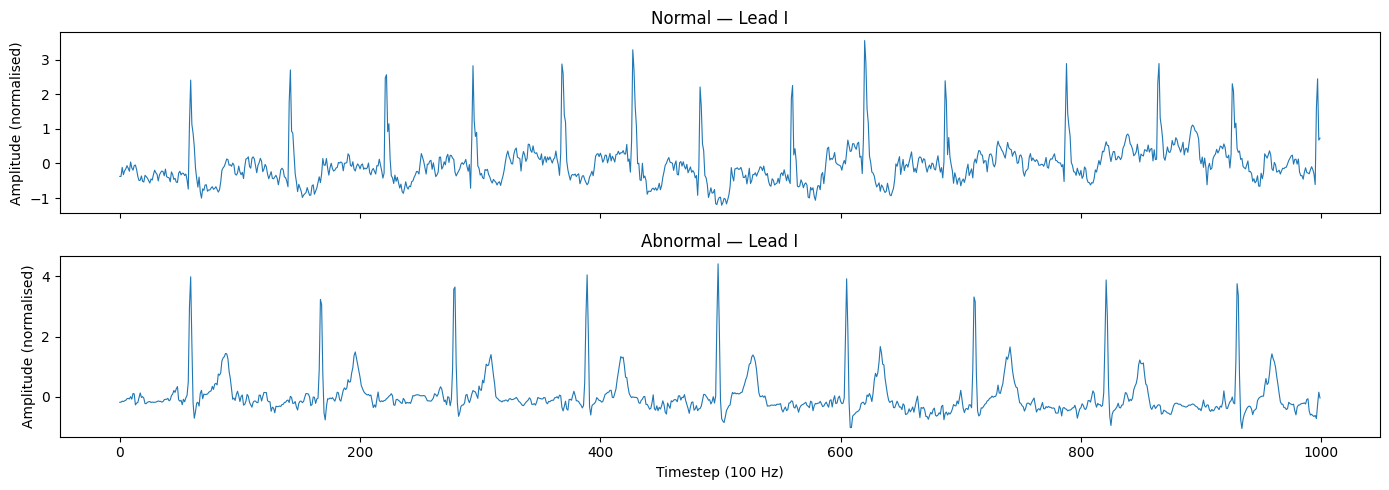

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
for ax, label, title in zip(axes, [1, 0], ['Normal', 'Abnormal']):
    idx = np.where(y_train == label)[0][0]
    ax.plot(X_train[idx, 0], linewidth=0.8)
    ax.set_title(f'{title} — Lead I')
    ax.set_ylabel('Amplitude (normalised)')
axes[-1].set_xlabel('Timestep (100 Hz)')
plt.tight_layout()
plt.show()

## 5. Dataset & DataLoaders

`PatchTSTForClassification` expects input shape `(batch, seq_len, n_channels)` — i.e. **time-first**, so we transpose from our leads-first format here.

In [13]:
class PTBXLDataset(Dataset):
    def __init__(self, X, y):
        # HuggingFace PatchTST expects (batch, seq_len, n_channels)
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)  # (N, 1000, 12)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


train_loader = DataLoader(PTBXLDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(PTBXLDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(PTBXLDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# sample_X, sample_y = next(iter(train_loader))
# print(f"Input shape per batch: {sample_X.shape}")  # expect (64, 1000, 12)
# print(f"Batches per epoch → train: {len(train_loader)}, val: {len(val_loader)}")

## 6. Build Model with HuggingFace PatchTST

In [ ]:
config = PatchTSTConfig(
    num_input_channels=N_LEADS,        # 12 ECG leads
    context_length=SEQ_LEN,            # 1000 timesteps
    patch_length=PATCH_SIZE,           # 50
    patch_stride=STRIDE,               # 25  (50% overlap)
    d_model=D_MODEL,                   # 128
    num_attention_heads=N_HEADS,       # 8
    num_hidden_layers=N_LAYERS,        # 4
    ffn_dim=D_MODEL * 4,               # 512
    dropout=DROPOUT,
    attention_dropout=DROPOUT,
    ff_dropout=DROPOUT,
    head_dropout=DROPOUT,
    positional_dropout=0.1,
    num_targets=N_CLASSES,             # 2  (normal / abnormal)
    pooling_type='mean',               # pool patch outputs before classification head
    norm_type='layernorm'
)

model = PatchTSTForClassification(config).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')
print(model.config)

Trainable parameters: 802,690
PatchTSTConfig {
  "activation_function": "gelu",
  "attention_dropout": 0.1,
  "bias": true,
  "channel_attention": false,
  "channel_consistent_masking": false,
  "context_length": 1000,
  "d_model": 128,
  "distribution_output": "student_t",
  "do_mask_input": null,
  "dropout": 0.1,
  "ff_dropout": 0.0,
  "ffn_dim": 512,
  "head_dropout": 0.0,
  "init_std": 0.02,
  "loss": "mse",
  "mask_type": "random",
  "mask_value": 0,
  "model_type": "patchtst",
  "norm_eps": 1e-05,
  "norm_type": "batchnorm",
  "num_attention_heads": 8,
  "num_forecast_mask_patches": [
    2
  ],
  "num_hidden_layers": 4,
  "num_input_channels": 12,
  "num_parallel_samples": 100,
  "num_targets": 2,
  "output_range": null,
  "patch_length": 50,
  "patch_stride": 25,
  "path_dropout": 0.0,
  "pooling_type": "mean",
  "positional_dropout": 0.0,
  "positional_encoding_type": "sincos",
  "pre_norm": true,
  "prediction_length": 24,
  "random_mask_ratio": 0.5,
  "scaling": "std",
  "s

## 7. Training

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)

            # HuggingFace model returns a ModelOutput object
            # logits are stored in .prediction_logits
            output = model(past_values=X)
            logits = output.prediction_logits          # (B, n_classes)

            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_patchtst.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print('\nTraining complete. Best model saved to best_patchtst.pt')

Epoch 01/30 | Train loss: 0.5305  acc: 0.7200 | Val loss: 0.4241  acc: 0.8010
Epoch 02/30 | Train loss: 0.4068  acc: 0.8140 | Val loss: 0.3611  acc: 0.8366
Epoch 03/30 | Train loss: 0.3732  acc: 0.8330 | Val loss: 0.3411  acc: 0.8446
Epoch 04/30 | Train loss: 0.3546  acc: 0.8428 | Val loss: 0.3331  acc: 0.8515
Epoch 05/30 | Train loss: 0.3433  acc: 0.8494 | Val loss: 0.3269  acc: 0.8572
Epoch 06/30 | Train loss: 0.3322  acc: 0.8533 | Val loss: 0.3284  acc: 0.8538
Epoch 07/30 | Train loss: 0.3211  acc: 0.8589 | Val loss: 0.3088  acc: 0.8664
Epoch 08/30 | Train loss: 0.3132  acc: 0.8629 | Val loss: 0.3704  acc: 0.8314
Epoch 09/30 | Train loss: 0.3062  acc: 0.8666 | Val loss: 0.3187  acc: 0.8515
Epoch 10/30 | Train loss: 0.2963  acc: 0.8712 | Val loss: 0.3057  acc: 0.8630
Epoch 11/30 | Train loss: 0.2842  acc: 0.8766 | Val loss: 0.3195  acc: 0.8555
Epoch 12/30 | Train loss: 0.2775  acc: 0.8824 | Val loss: 0.3189  acc: 0.8532
Epoch 13/30 | Train loss: 0.2656  acc: 0.8869 | Val loss: 0.3109

## 8. Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluation on Test Set

In [15]:
model.load_state_dict(torch.load('best_patchtst.pt', map_location=DEVICE))
model.eval()

all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for X, y in test_loader:
        output = model(past_values=X.to(DEVICE))
        logits = output.prediction_logits
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(y.numpy())

print(classification_report(all_labels, all_preds, target_names=['Abnormal', 'Normal']))
print(f"ROC-AUC: {roc_auc_score(all_labels, all_probs):.4f}")

/Users/fel/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    Abnormal       0.79      0.90      0.84      1903
      Normal       0.92      0.81      0.86      2457

    accuracy                           0.85      4360
   macro avg       0.85      0.86      0.85      4360
weighted avg       0.86      0.85      0.85      4360

ROC-AUC: 0.9282


### Confusion Matrix

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Abnormal', 'Normal'],
            yticklabels=['Abnormal', 'Normal'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — PatchTST')
plt.tight_layout()
plt.show()